In [103]:
with open("/content/drive/MyDrive/Colab Notebooks/Fundamentos de Ciencia de Datos/Rapunzel.txt","r", encoding = "utf-8") as archivo:
    rapunzel = archivo.read()

In [104]:
print(rapunzel[:500])

Había una vez una pareja que por mucho tiempo deseaba tener un bebé, hasta que por fin ese deseo se hizo realidad. A través de la ventana trasera de la pequeña casa donde vivían, podían ver un espléndido jardín que estaba lleno de las más bellas plantas y las más suculentas frutas y vegetales. El jardín estaba rodeado por un alto muro, y nadie se atrevía a entrar a él, porque pertenecía a una bruja muy malvada.

Un día, la mujer se asomó a la ventana y vio en el jardín un huerto de espinacas fre


In [105]:
len(rapunzel)

4895

In [106]:
rapunzel = rapunzel.lower()
rapunzel = rapunzel.replace(",","")
rapunzel = rapunzel.replace(";","")
rapunzel = rapunzel.replace(".","")
rapunzel = rapunzel.replace(":","")
rapunzel = rapunzel.replace("¡","")
rapunzel = rapunzel.replace("!","")
rapunzel = rapunzel.replace("?","")
rapunzel = rapunzel.replace("¿","")
rapunzel = rapunzel.replace("“","")
rapunzel = rapunzel.replace("—","")

In [107]:
len(rapunzel)

4760

In [108]:
palabras = rapunzel.split()

In [109]:
palabras[:20]

['había',
 'una',
 'vez',
 'una',
 'pareja',
 'que',
 'por',
 'mucho',
 'tiempo',
 'deseaba',
 'tener',
 'un',
 'bebé',
 'hasta',
 'que',
 'por',
 'fin',
 'ese',
 'deseo',
 'se']

In [110]:
import pandas as pd
import numpy as np

palabras_array =np.array(palabras)

In [111]:
len(palabras_array)

879

In [112]:
longitudes = np.array([len(palabra) for palabra in palabras_array])


In [113]:
print("Promedio", np.mean(longitudes))
print("Mediana", np.median(longitudes))
print("Minimo", np.min(longitudes))
print("Maximo", np.max(longitudes))

Promedio 4.383390216154721
Mediana 4.0
Minimo 1
Maximo 14


In [114]:
#Generar dataframe
df = pd.DataFrame(
      {
        "palabra":palabras

      }
    )
#Del DataFrame, me extraiga los 5 primeros resultados
df.head()

,palabra
0,había
1,una
2,vez
3,una
4,pareja


In [115]:
df["Longitud"] = df["palabra"].str.len()
df.head(10)

,palabra,Longitud
0,había,5
1,una,3
2,vez,3
3,una,3
4,pareja,6
5,que,3
6,por,3
7,mucho,5
8,tiempo,6
9,deseaba,7


In [116]:
frecuencias = df["palabra"].value_counts()
print(frecuencias.head(20))

palabra
la          53
que         30
y           29
el          28
a           25
de          25
rapunzel    24
un          18
bruja       17
se          17
en          12
su          12
al          12
por         11
torre       10
príncipe    10
una         10
estaba       8
tan          7
le           7
Name: count, dtype: int64


In [117]:
stopwords = [
    "el","que","en","de","del","y","la",
    "a","los","lo","al","un","te","las",
    "es","más","se","no","eso","si","le",
    "para","una","con","su","o","por","así",
    "pero", "tan", "tu", "él", "pero","como",
    "ella","muy"

]

In [118]:
df_clean = df[~df["palabra"].isin(stopwords)]

In [119]:
frecuencias = df_clean["palabra"].value_counts()
print(frecuencias.head(40))

palabra
rapunzel     24
bruja        17
torre        10
príncipe     10
estaba        8
espinacas     7
trenza        7
caer          6
vio           6
jardín        6
ventana       6
esposa        5
cuando        5
había         5
día           5
dijo          4
era           4
hermosa       4
malvada       4
deja          4
bosque        4
entrar        4
hombre        4
ver           4
voz           4
escalera      3
alto          3
años          3
bajo          3
niña          3
muro          3
escuchó       3
sin           3
sobre         3
hizo          3
hermoso       2
vez           2
mientras      2
días          2
todos         2
Name: count, dtype: int64


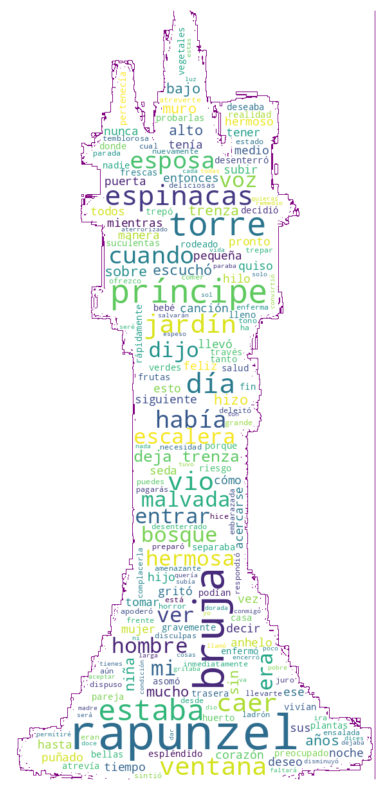

In [121]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt

mask_image = np.array(Image.open("/content/drive/MyDrive/Colab Notebooks/Fundamentos de Ciencia de Datos/Rapunzel-Mask.jpg"))

texto_limpio = " ".join(df_clean["palabra"])

nube = WordCloud(
    background_color="white",
    mask=mask_image,
    contour_width=1,
    contour_color="purple"
).generate(texto_limpio)

plt.figure(figsize=(10, 10))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.show()